In [15]:
from tqdm import tqdm

In [41]:
import pandas as pd
import seaborn as sns

sns.set()

In [72]:
from pathlib import Path
import re

In [2]:
hathi_path = Path("/mnt/data1/corpora/hathitrust/hathifiles/")

In [106]:
noveltm = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")

/tmp/ipykernel_262685/2643977125.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  noveltm = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")


In [5]:
fields = (hathi_path / "fields.txt").open().read().strip().split("\n")

In [146]:
noveltm.startdate.head(590)

0      ||||
1          
2          
3          
4          
       ... 
585     195
586    1933
587    1701
588    1702
589    1703
Name: startdate, Length: 590, dtype: object

In [147]:
fields

['htid',
 'access',
 'rights',
 'ht_bib_key',
 'description',
 'source',
 'source_bib_num',
 'oclc_num',
 'isbn',
 'issn',
 'lccn',
 'title',
 'imprint',
 'rights_reason_code',
 'rights_timestamp',
 'us_gov_doc_flag',
 'rights_date_used',
 'pub_place',
 'lang',
 'bib_fmt',
 'collection_code',
 'content_provider_code',
 'responsible_entity_code',
 'digitization_agent_code',
 'access_profile_code',
 'author']

In [114]:
noveltm_corpus = []
idds = set()
noveltm_books = set(noveltm.docid)
paths = []
for line in tqdm((hathi_path / "english_texts.txt").open()):
    parts = line.strip().split("\t")
    allowed = parts[1][0] == "a"

    htid = parts[0]
    if allowed and htid in noveltm_books:
        noveltm_corpus.append(parts)
    # path = re.sub(":", "+", path)
    # path = re.sub("/", "=", path)
    # id_prefix = path.split(".")[0]
    # id_suffix = ".".join(path.split(".")[1:])
    # if id_suffix in noveltm_books:
    #     paths.append(str(Path("/mnt/data1/dbamman/ppa_hathi") / f"{id_suffix}.txt"))
    #     in_corpus.append(parts)
    #     idds.add(id_suffix)
    # print(id_prefix)
    # print(id_suffix)
    # break

9469263it [00:24, 392089.85it/s]


In [115]:
len(noveltm_corpus)

44205

In [161]:
noveltm_keep = ([int(novel[16]) <= 1923 if len(novel[16]) == 4 else False for novel in noveltm_corpus])

In [170]:
noveltm_df = pd.DataFrame(
    [novel for keep, novel in zip(noveltm_keep, noveltm_corpus) if keep],
    columns=fields
)

In [183]:
noveltm_df[noveltm_df.rights_date_used.astype(int) >= 1800].htid.to_csv("../data/hathimeta/noveltm.pub.txt", index=False, header=False)

In [180]:
noveltm_df.rights_date_used.astype(int)[lambda x: x >= 1820]

0        1916
1        1894
2        1918
3        1916
4        1898
         ... 
39747    1905
39748    1905
39749    1905
39750    1895
39751    1895
Name: rights_date_used, Length: 38145, dtype: int64

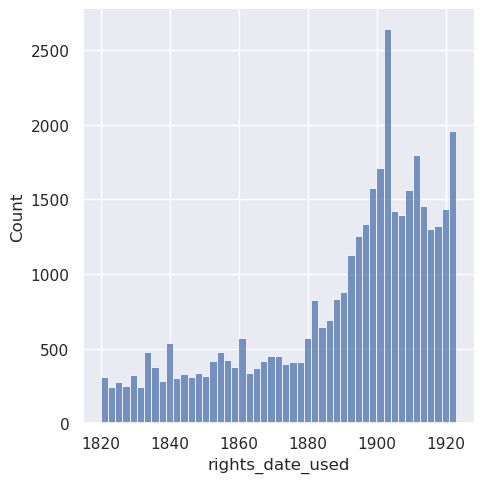

In [179]:
sns.displot(noveltm_df.rights_date_used.astype(int)[lambda x: x >= 1820])

In [169]:
with open("../data/hathimeta/noveltm.pub.txt", "w") as f:
    f.write("\n".join([novel[0] for keep, novel in zip(noveltm_keep, noveltm_corpus) if keep]))
    f.write("\n")

In [102]:
in_corpus = []
idds = set()
bamman_books = set([
    b.stem for b in Path("/mnt/data1/dbamman/ppa_hathi").glob("*.txt")
])
paths = []
for line in tqdm((hathi_path / "english_texts.txt").open()):
    parts = line.strip().split("\t")
    allowed = parts[1][0] == "a"

    path = parts[0]
    path = re.sub(":", "+", path)
    path = re.sub("/", "=", path)
    id_prefix = path.split(".")[0]
    id_suffix = ".".join(path.split(".")[1:])
    if id_suffix in bamman_books:
        paths.append(str(Path("/mnt/data1/dbamman/ppa_hathi") / f"{id_suffix}.txt"))
        in_corpus.append(parts)
        idds.add(id_suffix)
    # print(id_prefix)
    # print(id_suffix)
    # break

9469263it [00:37, 255873.52it/s]


In [103]:
df = pd.DataFrame(in_corpus, columns=fields)

In [104]:
df["path"] = paths

In [105]:
df.to_csv("../data/hathitrust_meta.csv", index=False)

In [101]:
df["path"]

0                                                  None
1                                                  None
2       /mnt/data1/dbamman/ppa_hathi/32044098628373.txt
3               /mnt/data1/dbamman/ppa_hathi/ah3lwd.txt
4               /mnt/data1/dbamman/ppa_hathi/ah3lw5.txt
                             ...                       
4697    /mnt/data1/dbamman/ppa_hathi/32044089137780.txt
4698    /mnt/data1/dbamman/ppa_hathi/32044080200538.txt
4699            /mnt/data1/dbamman/ppa_hathi/hx2aen.txt
4700    /mnt/data1/dbamman/ppa_hathi/39015009191142.txt
4701    /mnt/data1/dbamman/ppa_hathi/39015031040416.txt
Name: path, Length: 4702, dtype: object

In [94]:
years = df.rights_date_used.astype(int)

In [95]:
bamman_books - idds

{'$b252328',
 '$b257440',
 '30000011386830',
 '32101055566879',
 '33433022673234',
 '33433069240988',
 '33433069240996',
 '33433074393160',
 '33433074860689',
 '33433074860697',
 '33433074860705',
 '39015004794387',
 '39015008683255',
 '39015013425254',
 '39015014739869',
 '39015015356457',
 '39015030869138',
 '39015030996907',
 '39015041742746',
 '39015062916807',
 '39015065553417',
 '39015065700703',
 '39015070340412',
 'aa0013985734',
 'ah62kv',
 'ark+=13960=t5q85628k',
 'cu58976523',
 'x030751028'}

In [96]:
len(years)

4702

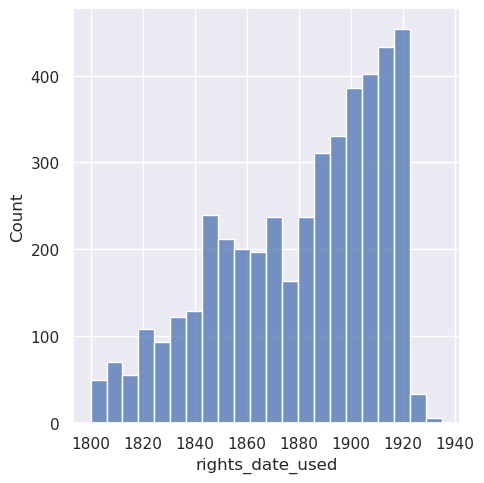

In [97]:
sns.displot(years[years.lt(9999) & years.ge(1800)])

In [98]:
df.access.value_counts()

access
allow    4702
Name: count, dtype: int64

In [6]:
fields

['htid',
 'access',
 'rights',
 'ht_bib_key',
 'description',
 'source',
 'source_bib_num',
 'oclc_num',
 'isbn',
 'issn',
 'lccn',
 'title',
 'imprint',
 'rights_reason_code',
 'rights_timestamp',
 'us_gov_doc_flag',
 'rights_date_used',
 'pub_place',
 'lang',
 'bib_fmt',
 'collection_code',
 'content_provider_code',
 'responsible_entity_code',
 'digitization_agent_code',
 'access_profile_code',
 'author']